In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
df= pd.read_csv("loan_approved.csv")

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.shape

(614, 13)

In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [8]:
#dependences is object convet to int

In [9]:
df.drop("Loan_ID",axis=1,inplace= True)

In [10]:
num_col=df.select_dtypes(include=['int64','float64'])
num_col

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


In [11]:
cat_col=df.select_dtypes(include=['object'])
cat_col

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status (Approved)
0,Male,No,0,Graduate,No,Urban,Y
1,Male,Yes,1,Graduate,No,Rural,N
2,Male,Yes,0,Graduate,Yes,Urban,Y
3,Male,Yes,0,Not Graduate,No,Urban,Y
4,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,Rural,Y
610,Male,Yes,3+,Graduate,No,Rural,Y
611,Male,Yes,1,Graduate,No,Urban,Y
612,Male,Yes,2,Graduate,No,Urban,Y


In [12]:
#find all the unique values
for k in cat_col:
  k = df[k].unique()
  print(k)

['Male' 'Female' nan]
['No' 'Yes' nan]
['0' '1' '2' '3+' nan]
['Graduate' 'Not Graduate']
['No' 'Yes' nan]
['Urban' 'Rural' 'Semiurban']
['Y' 'N']


In [13]:
for k in cat_col:
  k = df[k].value_counts()
  print(k)

Gender
Male      489
Female    112
Name: count, dtype: int64
Married
Yes    398
No     213
Name: count, dtype: int64
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
Loan_Status (Approved)
Y    422
N    192
Name: count, dtype: int64


In [14]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [15]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

In [16]:
df.loc[:,"Married"]=df.loc[:,"Married"].fillna(df.loc[:,"Married"].mode()[0])

In [17]:
df.loc[:,"Self_Employed"]=df.loc[:,"Self_Employed"].fillna(df.loc[:,"Self_Employed"].mode()[0])

In [18]:
df.loc[:,"Dependents"]=df.loc[:,"Dependents"].fillna(df.loc[:,"Dependents"].mode()[0])

In [19]:
#use mode because it has only 2 values
df.loc[:,"Credit_History"]=df.loc[:,"Credit_History"].fillna(df.loc[:,"Credit_History"].mode()[0])

In [20]:
df.loc[:,"LoanAmount"]=df.loc[:,"LoanAmount"].fillna(df.loc[:,"LoanAmount"].median())

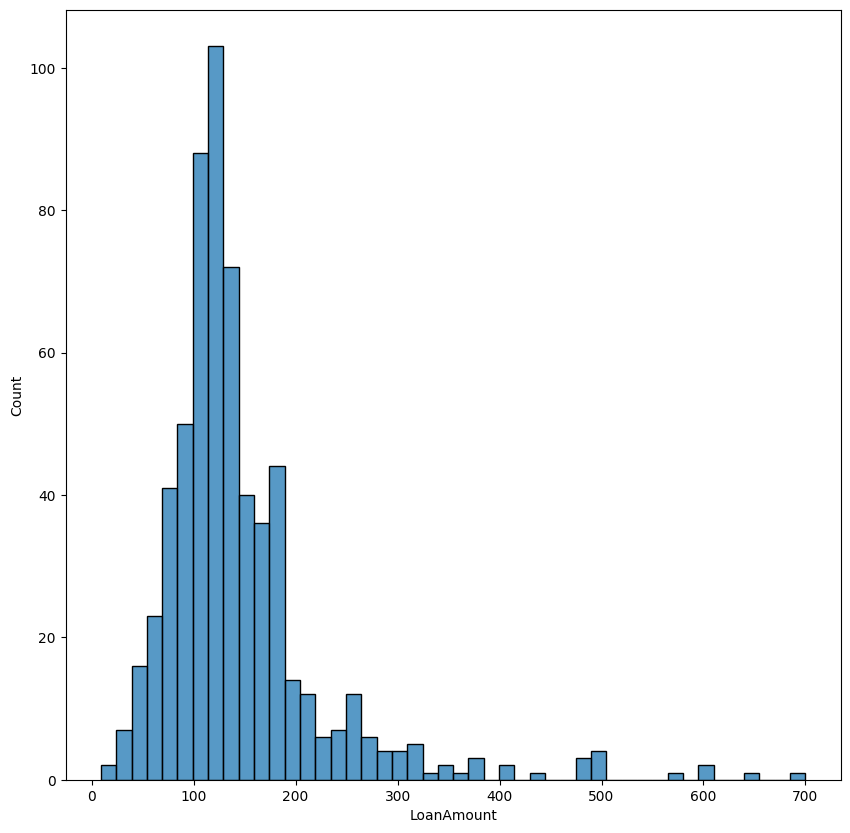

In [21]:
plt.figure(figsize=(10,10))
sns.histplot(df,x='LoanAmount')
plt.show()

In [22]:
df['LoanAmount'].skew()

np.float64(2.743052748820892)

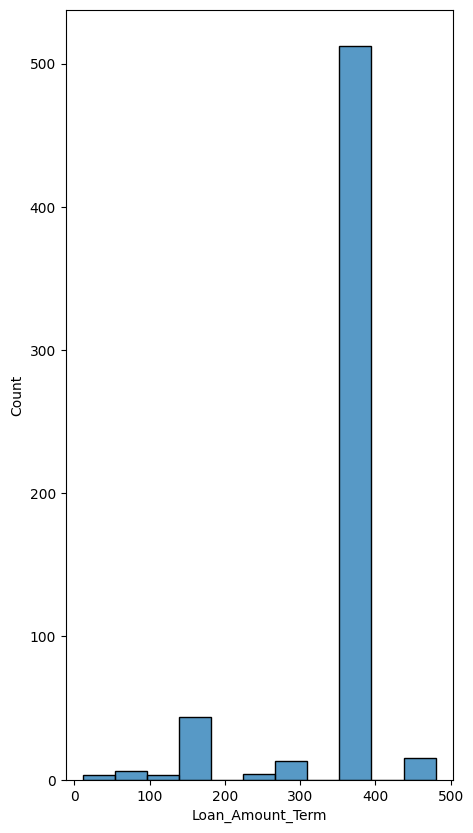

In [23]:
plt.figure(figsize=(5,10))
sns.histplot(df,x='Loan_Amount_Term')
plt.show()

In [24]:
df['Loan_Amount_Term'].skew()

np.float64(-2.362414124216269)

In [25]:
df.loc[:,"Loan_Amount_Term"]=df.loc[:,"Loan_Amount_Term"].fillna(df.loc[:,"Loan_Amount_Term"].median())

In [26]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [27]:
#handling outliers

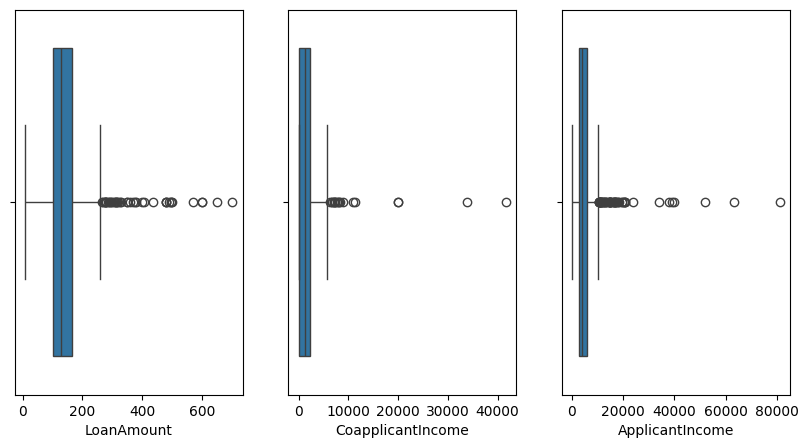

In [28]:
fig,ax=plt.subplots(1,3,figsize=(10,5))
sns.boxplot(df,x='LoanAmount',ax=ax[0])
sns.boxplot(df,x='CoapplicantIncome',ax=ax[1])
sns.boxplot(df,x='ApplicantIncome',ax=ax[2])
plt.show()

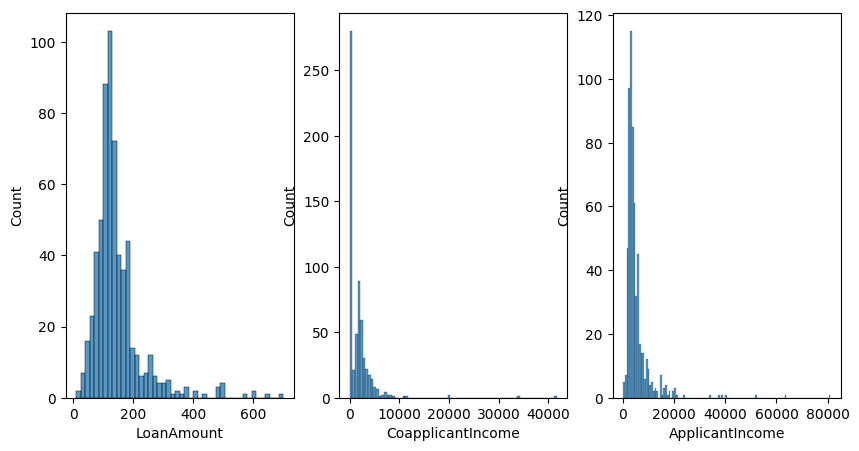

In [29]:
fig,ax=plt.subplots(1,3,figsize=(10,5))
sns.histplot(df,x='LoanAmount',ax=ax[0])
sns.histplot(df,x='CoapplicantIncome',ax=ax[1])
sns.histplot(df,x='ApplicantIncome',ax=ax[2])
plt.show()

In [30]:
Q1 = df['ApplicantIncome'].quantile(0.25)
Q3 = df['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers


In [31]:
outliers = df[(df.loc[:,'ApplicantIncome'] > upper_bound) | (df.loc[:,'ApplicantIncome'] < lower_bound)]


In [32]:
len(outliers)

50

In [33]:
(len(outliers)/len(df))*100

8.143322475570033

In [34]:
q1_coapp=df['CoapplicantIncome'].quantile(0.25)
q3_coapp=df['CoapplicantIncome'].quantile(0.75)
IQR_coapp=q3_coapp-q1_coapp
upper_bound_coapp=q3_coapp+1.5*IQR_coapp
lower_bound_coapp=q1_coapp-1.5*IQR_coapp

In [35]:
df[(df['CoapplicantIncome']>upper_bound_coapp)|(df["CoapplicantIncome"]<lower_bound_coapp)]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
9,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N
12,Male,Yes,2,Graduate,No,3073,8106.0,200.0,360.0,1.0,Urban,Y
38,Male,No,0,Graduate,No,4166,7210.0,184.0,360.0,1.0,Urban,Y
122,Female,No,0,Graduate,No,2137,8980.0,137.0,360.0,0.0,Semiurban,Y
135,Male,Yes,3+,Graduate,No,4000,7750.0,290.0,360.0,1.0,Semiurban,N
177,Male,Yes,3+,Graduate,No,5516,11300.0,495.0,360.0,0.0,Semiurban,N
180,Male,Yes,1,Graduate,No,6400,7250.0,180.0,360.0,0.0,Urban,N
253,Male,Yes,1,Not Graduate,No,2661,7101.0,279.0,180.0,1.0,Semiurban,Y
349,Male,Yes,0,Graduate,No,2625,6250.0,187.0,360.0,1.0,Rural,Y
372,Male,Yes,2,Graduate,Yes,9323,7873.0,380.0,300.0,1.0,Rural,Y


In [36]:
(len(df[(df['CoapplicantIncome']>upper_bound_coapp)|(df["CoapplicantIncome"]<lower_bound_coapp)])/len(df))*100

2.9315960912052117

In [37]:
df.loc[(df['CoapplicantIncome'] > upper_bound_coapp) | (df['CoapplicantIncome'] < lower_bound_coapp), 'CoapplicantIncome'] = df['CoapplicantIncome'].median()

print("Outliers in CoapplicantIncome after capping with median:")
print(df[(df['CoapplicantIncome'] > upper_bound_coapp) | (df['CoapplicantIncome'] < lower_bound_coapp)][['CoapplicantIncome']])

Outliers in CoapplicantIncome after capping with median:
Empty DataFrame
Columns: [CoapplicantIncome]
Index: []


In [38]:
Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers


In [39]:
df[(df['LoanAmount']>upper_bound)|(df['LoanAmount']<lower_bound)]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
9,Male,Yes,1,Graduate,No,12841,1188.5,349.0,360.0,1.0,Semiurban,N
21,Male,Yes,1,Graduate,No,5955,5625.0,315.0,360.0,1.0,Urban,Y
34,Male,No,3+,Graduate,No,12500,3000.0,320.0,360.0,1.0,Rural,N
54,Female,Yes,1,Graduate,Yes,11500,0.0,286.0,360.0,0.0,Urban,N
67,Male,Yes,1,Graduate,No,10750,0.0,312.0,360.0,1.0,Urban,Y
83,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,1.0,Semiurban,N
126,Male,Yes,3+,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
130,Male,No,0,Graduate,Yes,20166,0.0,650.0,480.0,1.0,Urban,Y
135,Male,Yes,3+,Graduate,No,4000,1188.5,290.0,360.0,1.0,Semiurban,N


In [40]:
(len(df[(df['LoanAmount']>upper_bound)|(df['LoanAmount']<lower_bound)])/len(df))*100

6.677524429967427

In [41]:
#Encoding

In [42]:
#Gender #onehotencoding
#married: label encode
#education:target encoding
#Self_employed:label encoder
#proper_aread:target encoder
#loan_status(approve):label encoder
#dependences:replace 3_+ with 3

In [43]:
from sklearn.preprocessing import  LabelEncoder
le=LabelEncoder()
df['married']=le.fit_transform(df['Married'])
df['self_employed']=le.fit_transform(df['Self_Employed'])
df['loan_status']=le.fit_transform(df['Loan_Status (Approved)'])




In [44]:
df.drop(columns=['Married','Self_Employed','Loan_Status (Approved)'],inplace=True)

In [45]:
df=pd.get_dummies(df,columns=['Gender'],dtype='int')

In [46]:
df.head()

,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,married,self_employed,loan_status,Gender_Female,Gender_Male
0,0,Graduate,5849,0.0,128.0,360.0,1.0,Urban,0,0,1,0,1
1,1,Graduate,4583,1508.0,128.0,360.0,1.0,Rural,1,0,0,0,1
2,0,Graduate,3000,0.0,66.0,360.0,1.0,Urban,1,1,1,0,1
3,0,Not Graduate,2583,2358.0,120.0,360.0,1.0,Urban,1,0,1,0,1
4,0,Graduate,6000,0.0,141.0,360.0,1.0,Urban,0,0,1,0,1


In [47]:
df['education']=df['Education'].map({'Graduate':1,'Not Graduate':0})

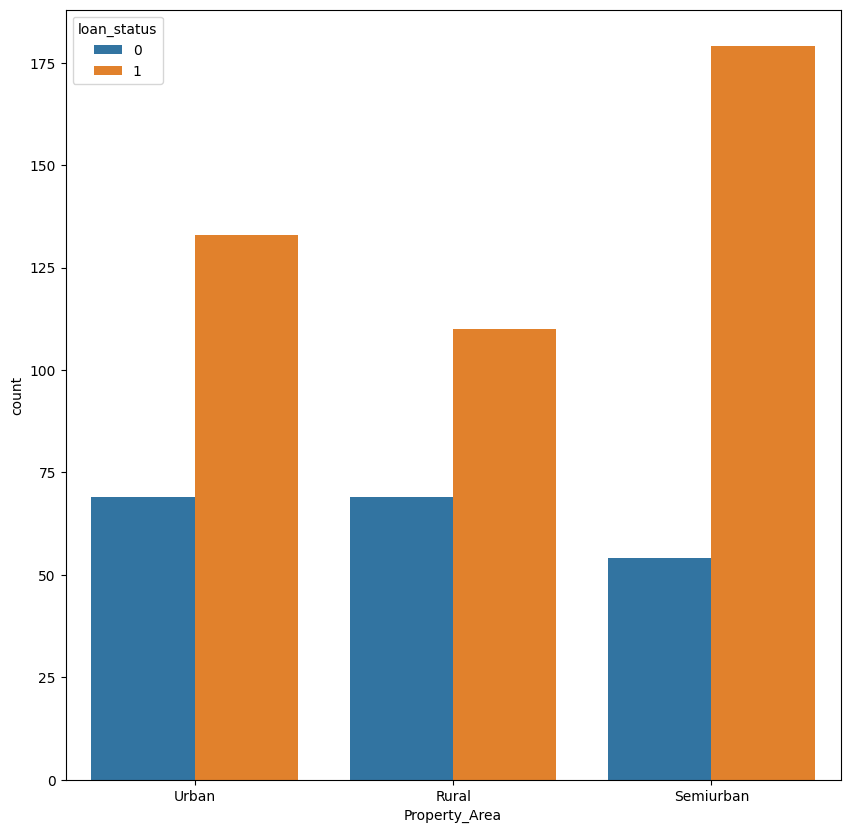

In [48]:
plt.figure(figsize=(10,10))
sns.countplot(df,x='Property_Area',hue="loan_status")
plt.show()

In [49]:
df['property_Area']=df['Property_Area'].map({'Urban':1,'Rural':0,'Semiurban':2})

In [50]:
df.drop(columns=['Property_Area','Education'],inplace=True)

In [51]:
df['Dependents']=df['Dependents'].replace('3+',3)


In [52]:
df['dependents']=df['Dependents'].astype('int')

In [53]:
df.drop(columns='Dependents',inplace=True)

In [54]:
df


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,married,self_employed,loan_status,Gender_Female,Gender_Male,education,property_Area,dependents
0,5849,0.0,128.0,360.0,1.0,0,0,1,0,1,1,1,0
1,4583,1508.0,128.0,360.0,1.0,1,0,0,0,1,1,0,1
2,3000,0.0,66.0,360.0,1.0,1,1,1,0,1,1,1,0
3,2583,2358.0,120.0,360.0,1.0,1,0,1,0,1,0,1,0
4,6000,0.0,141.0,360.0,1.0,0,0,1,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0,0,0,1,1,0,1,0,0
610,4106,0.0,40.0,180.0,1.0,1,0,1,0,1,1,0,3
611,8072,240.0,253.0,360.0,1.0,1,0,1,0,1,1,1,1
612,7583,0.0,187.0,360.0,1.0,1,0,1,0,1,1,1,2


In [55]:
#apply scaling
from sklearn.preprocessing import StandardScaler
model=StandardScaler()
df["ApplicantIncome"]=model.fit_transform(df[["ApplicantIncome"]])
df['CoapplicantIncome']=model.fit_transform(df[["CoapplicantIncome"]])
df['LoanAmount']=model.fit_transform(df[["LoanAmount"]])
df['Loan_Amount_Term']=model.fit_transform(df[["Loan_Amount_Term"]])

In [56]:
#split data


In [57]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [58]:
#smote

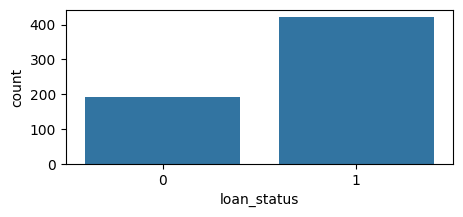

In [59]:
plt.figure(figsize=(5,2))
sns.countplot(df,x='loan_status')
plt.show()

In [60]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_sampled,y_sampled=smote.fit_resample(X_train,y_train)

In [61]:
from collections import Counter
Counter(y_train)

Counter({0: 149, 1: 342})

In [62]:
Counter(y_sampled)

Counter({0: 342, 1: 342})

In [72]:
#mlp classifier
from sklearn.neural_network import MLPClassifier
model=MLPClassifier()
model.fit(x_sampled,y_sampled)
y_pred=model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [73]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(f1_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))

0.7479674796747967
[[23 20]
 [11 69]]
              precision    recall  f1-score   support

           0       0.68      0.53      0.60        43
           1       0.78      0.86      0.82        80

    accuracy                           0.75       123
   macro avg       0.73      0.70      0.71       123
weighted avg       0.74      0.75      0.74       123

0.8165680473372781
0.7752808988764045
0.8625


In [91]:
#mlp classifier
from sklearn.neural_network import MLPClassifier
model=MLPClassifier(hidden_layer_sizes=(100,100,100),activation='relu',solver='adam',random_state=42)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [92]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(f1_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))

0.6991869918699187
[[20 23]
 [14 66]]
              precision    recall  f1-score   support

           0       0.59      0.47      0.52        43
           1       0.74      0.82      0.78        80

    accuracy                           0.70       123
   macro avg       0.66      0.65      0.65       123
weighted avg       0.69      0.70      0.69       123

0.7810650887573964
0.7415730337078652
0.825
